# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np
from scipy.special import expit

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.dgp import DataGenerationProcess, Targeting
from core.targeting import *
from core.variables import *

# DGP

In [ ]:
class Targeting(DataGenerationProcess):
    valid_response_types = ['continuous', 'bernoulli', 'logit']
    def __init__(
        self, 
        base_effect_vars: list[np.ndarray],
        cust_feat_var: RandomVariable, 
        char_func: callable, 
        noise_vars: list[ContinuousRandomVariable] = None, 
        response_type: str = 'continuous', 
        dgp_seed: int = 0
    ):
        """
        Data generation process for targeting with continuous segments and discrete treatments. 

        DGP: 
            - Y_i = \sum_{t} (\tau_t * g(X_i) + \epsilon_{it}) 1{T_i = t}

        Params:
        -------
        base_effect_vars: list[np.ndarray]
            List of base treatment effect variables for each treatment.
        cust_feat_var: RandomVariable
            Random variable for customer features.
        char_func: callable
            Characteristic function (g) for segment assignment.
        noise_vars: list[ContinuousRandomVariable], default to None
            List of noise variables for each treatment. 
        response_type: str
            Type of response variable. Can be 'continuous', 'bernoulli', or 'logit'.
        dgp_seed: int
            Random seed for the causal effects. 
        """
        if dgp_seed is not None:
            np.random.seed(dgp_seed)

        assert response_type in self.valid_response_types, "Response type should be continuous, bernoulli, or logit."
        if response_type == 'continuous':
            assert noise_vars is not None, "Noise standard deviation should be provided for continuous response type."
        if response_type == 'bernoulli':
            assert np.all([0 < dstn.mean < 1 for dstn in base_effect_vars]), "Bernoulli response type requires 0 < mean < 1 for all treatments."

        self.base_effect_vars = base_effect_vars  # shape = (n_treatments, )
        self.cust_feat_var = cust_feat_var
        self.char_func = char_func
        self.noise_vars = noise_vars  # shape = (n_treatments, )
        self.response_type = response_type

        # extract attributes
        self.n_treatments = len(base_effect_vars)
        self.treatment_space = np.arange(self.n_treatments)

        # draw true effects, shape = (n_treatments, )
        self.base_effects = self.draw_true_effects(seed=dgp_seed)  # shape = (n_treatments, n_features)

    def draw_true_effects(self, seed: int = None):
        if seed is not None:
            np.random.seed(seed)

        return np.array([dstn.sample(1) for dstn in self.base_effect_vars])  # shape = (n_treatments, n_features)

    def sample_individuals(self, sample_size: int, seed: int = None) -> np.ndarray:
        """ 
        Sample individuals from the DGP. 
        """
        if seed is not None:
            np.random.seed(seed)

        # draw customer features
        cust_features = self.cust_feat_var.sample(sample_size)

        # check if the customer features are 1D, reshape if necessary
        if len(cust_features.shape) == 1:  # shape = (sample_size, )
            cust_features = cust_features.reshape(-1, 1)  # reshape to (sample_size, 1)

        return cust_features  # shape = (sample_size, n_features)

    def sample(self, sample_size, seed: int = None) -> tuple:
        """ 
        Sample data from the DGP. 

        Params:
        -------
        sample_size: int
            Number of individuals to sample.
        seed: int
            Random seed for reproducibility.

        Returns:
        --------
        tuple: 
            - cust_features: np.ndarray, shape = (sample_size, n_features)
            - treatments: np.ndarray, shape = (sample_size, )
            - outcomes: np.ndarray, shape = (sample_size, )
        """
        if seed is not None:
            np.random.seed(seed)

        # sample individual customers
        cust_feat_arr = self.sample_individuals(sample_size)  # shape = (sample_size, n_features)

        # assign treatments 
        treatment_arr = np.random.choice(self.n_treatments, size=sample_size)  # shape = (sample_size, )

        # calcualte treatment effects, shape = (sample_size, )
        full_te_arr = self.predict_treatment_effect(cust_feat_arr)  # shape = (sample_size, n_treatments)

        # calculate treatment effects for each customer
        cust_te_arr = full_te_arr[np.arange(sample_size), treatment_arr]

        # generate outcomes 
        if self.response_type == 'continuous':
            # generate noise for each treatment, # shape = (n_treatments, sample_size)
            treatment_noise_arr = np.array([dstn.sample(sample_size) for dstn in self.noise_vars])

            outcome_arr = cust_te_arr + treatment_noise_arr[treatment_arr, np.arange(sample_size)]  # shape = (sample_size, )
        
        elif self.response_type == 'bernoulli':
            outcome_arr = np.random.binomial(1, cust_te_arr)  # shape = (sample_size, )

        elif self.response_type == 'logit':
            purchase_proba = 1 - expit(-cust_te_arr)  # shape = (sample_size, )
            outcome_arr = np.random.binomial(1, purchase_proba)  # shape = (sample_size, )

        return cust_feat_arr, treatment_arr, outcome_arr

    def predict_treatment_effect(self, cust_features: np.ndarray) -> np.ndarray:
        """ 
        Predict the treatment effects for a given set of customers. 

        Params:
        -------
        cust_features: np.ndarray, shape = (sample_size, n_features)
            Customer data with covariates.

        Returns:
        --------
        np.ndarray, shape = (sample_size, n_treatments)
            Predicted treatment effects for each customer under each treatment.
        """
        return self.char_func(cust_features) * np.repeat(self.base_effects.T, cust_features.shape[0], axis=0)
    
    def predict_incremental_effect(self, cust_features: np.ndarray) -> np.ndarray:
        """ 
        Predict the incremental treatment effects for a given set of customers 
        against the control group (0th treatment).

        Params:
        -------
        cust_features: np.ndarray, shape = (sample_size, n_features)
            Customer data with covariates.

        Returns:
        --------
        np.ndarray, shape = (sample_size, n_treatments - 1)
            Predicted incremental treatment effects for each customer under each treatment.
        """
        full_te_arr = self.predict_treatment_effect(cust_features)

        return (full_te_arr - full_te_arr[:, 0].reshape(-1, 1))[:, 1:]  # shape = (sample_size, n_treatments - 1)

In [5]:
dgp_params = {
    'base_effects': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2, 
    'noise_vars': [UnivariateGaussian(0, 1), UnivariateGaussian(0, 1)], 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

# dgp_params = {
#     'base_effects': [PointMass(0.1), PointMass(0.11)], 
#     'cust_feat_var': Uniform(0, 1), 
#     'char_func': lambda x: x**2 + x, 
#     'response_type': 'bernoulli', 
#     'dgp_seed': 0
# }

# instantiate the DGP
dgp = Targeting(**dgp_params)

In [6]:
# sample 
cust_features, treatments, outcomes = dgp.sample(1000)
oos_cust_features = dgp.sample_individuals(5000)

# Estimation

In [7]:
cf1 = CausalForest(
    n_estimators=500, max_depth=None, criterion='het', n_jobs=-1
).fit(X=cust_features, Y=outcomes, T=treatments, )

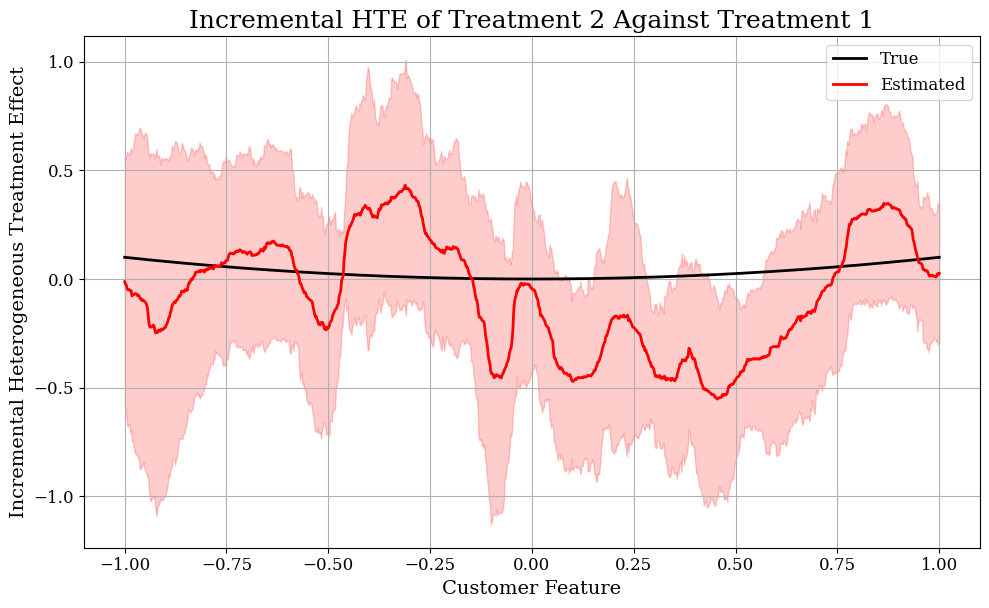

In [8]:
plot_incremental_hte(dgp, cf1, ci=True)

# Selection

In [ ]:
def obj_func(
    selection: np.ndarray, 
    cust_feautres: np.ndarray, 
    demand_model, 
    treatment_effects: np.ndarray = None
) -> float:
    """
    Objective function to be maximized by the targeting algorithm. 
    This is the expected value of the treatment effect for the selected customers. 
    """
    if treatment_effects is None:
        treatment_effects = demand_model.predict_incremental_effect(cust_feautres)  # shape = (sample_size, n_treatments - 1)
    else:
        assert treatment_effects.shape[0] == selection.shape[0], "Treatment effects must be the same length as the selection vector."

    # calculate the expected value of the treatment effect for the selected customers
    return treatment_effects[np.arange(selection.shape[0]), selection].mean()

def optimize(demand_model, cust_features: np.ndarray) -> tuple:
    """ 
    Optimize targeting decision

    Params:
    -------
    demand_model: object
        demand model

    cust_features: np.ndarray, shape=(n_customers, n_features)
        features of the individuals

    treatment_space: np.ndarray, shape=(n_treatments, )
        treatment space

    Returns:
    --------
    tuple
        optimal decision, optimal value
    """
    # calculate objective values under each treatment
    te_arr = demand_model.predict_incremental_effect(cust_features)  # shape = (sample_size, n_treatments - 1)

    # add the control group to the treatment effects
    te_arr = np.hstack((np.zeros((te_arr.shape[0], 1)), te_arr))  # shape = (sample_size, n_treatments)

    # choose the better treatment for each customer 
    opt_decision = np.argmax(te_arr, axis=1)  # shape = (sample_size, )

    # calculate the optimal value
    opt_value = obj_func(
        selection=opt_decision, 
        cust_feautres=cust_features, 
        demand_model=demand_model,
        treatment_effects=te_arr
    )

    return opt_decision, opt_value

In [12]:
selection, val_Est = optimize(cf1, oos_cust_features)

In [38]:
decision, val_est = optimize(demand_model=cf1, cust_features=oos_cust_features)

In [42]:
emp_te_arr = cf1.predict_effect(oos_cust_features)
true_te_arr = dgp.predict_effect(oos_cust_features)

# Evaluation

In [39]:
val_true = obj_func(
    selection=decision, 
    cust_feautres=oos_cust_features, 
    demand_model=dgp,
)

result_df = pd.DataFrame({
    'Policy Value': [val_est, val_true, val_est - val_true]
}, index=['Estimated', 'True', "Winner's Curse"])
result_df

,Policy Value
Estimated,0.472058
True,1.059648
Winner's Curse,-0.587590


In [285]:
del dgp, cf1, cust_features, treatments, outcomes
del x, est_te_arr, est_diff_arr, true_te_arr, true_diff_arr
del decision, val_est, val_true, result_df

# Winner's Curse